<a href="https://colab.research.google.com/github/Arpita-07-ux/Portfolio-/blob/main/seasonal_agriculture_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha     

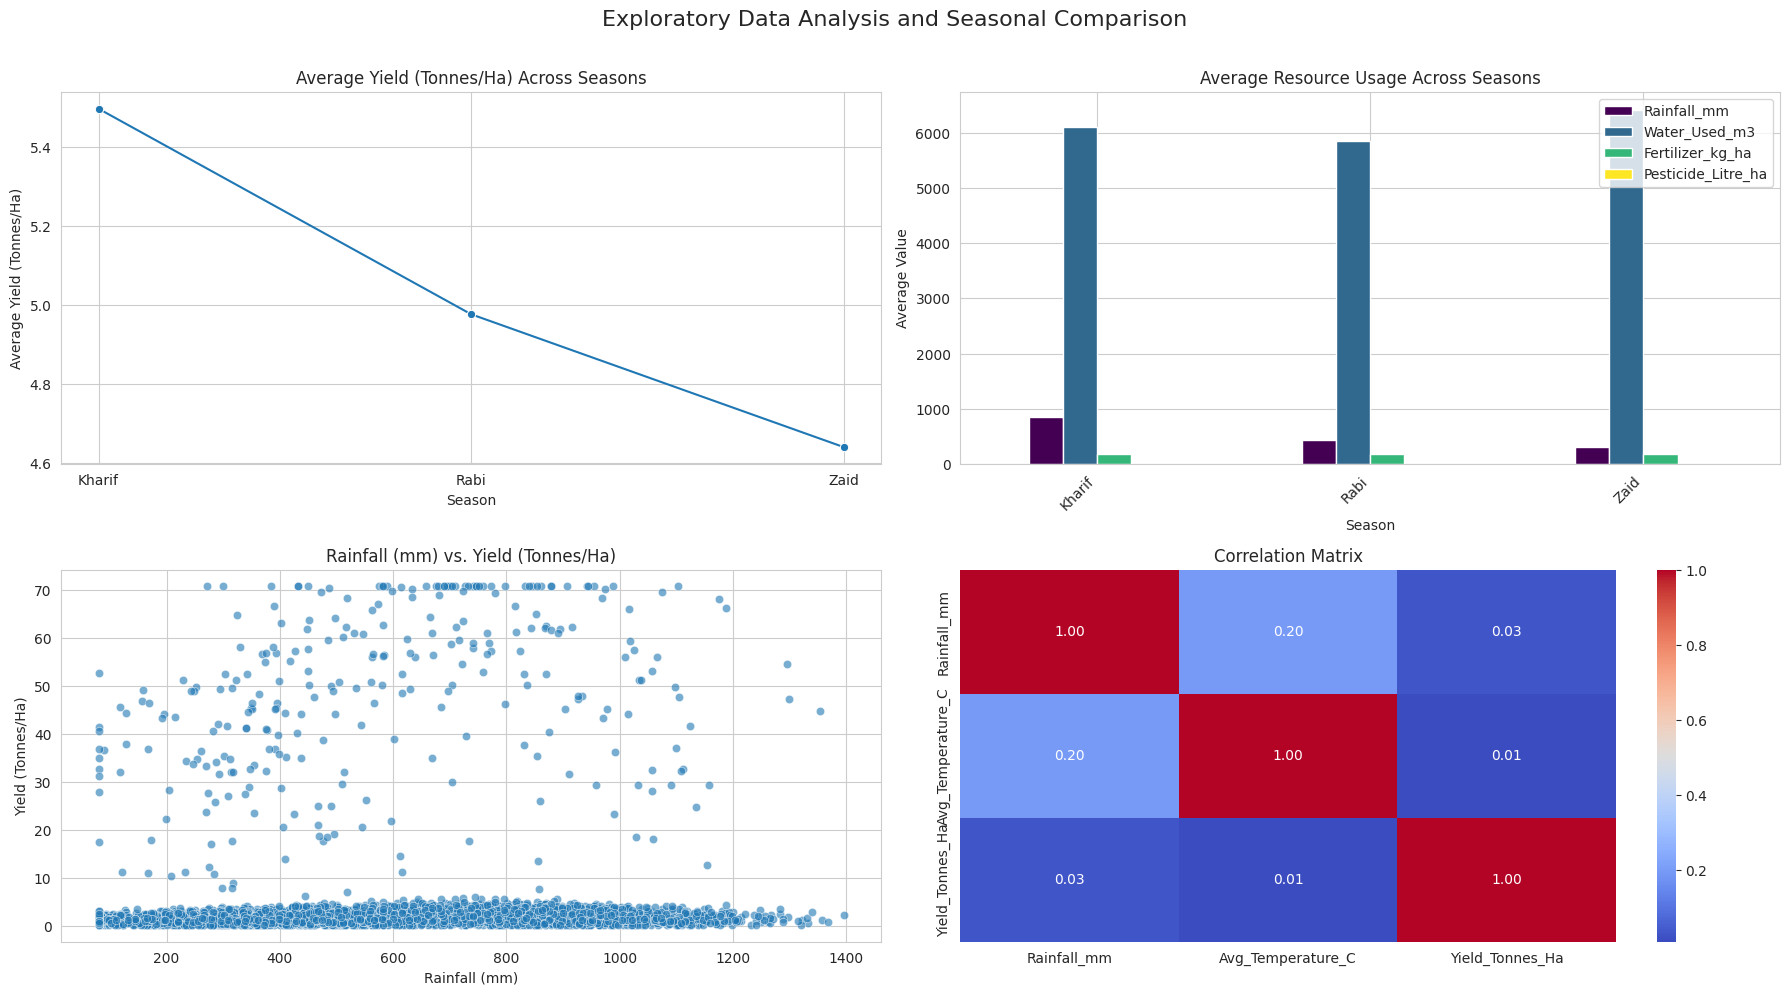

/tmp/ipykernel_561/792071616.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seasonal_summary.index, y='Profit_INR', data=seasonal_summary, palette='crest')


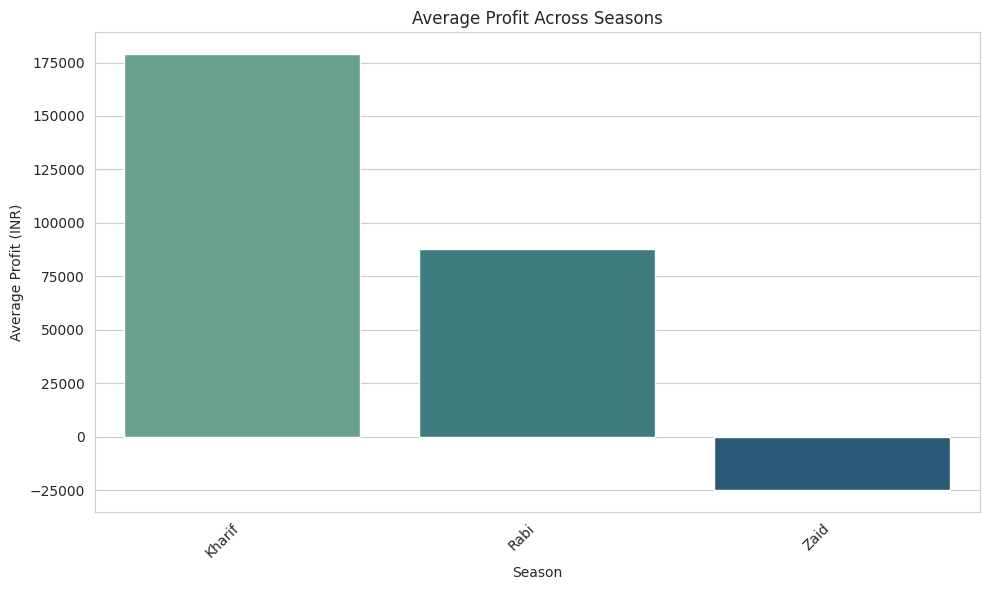


--- Analysis Complete ---
Cleaned dataset (with base for analysis) saved as 'cleaned_agriculture_dataset_with_analysis_base.csv'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

# -----------------------------
# 1. Inspect the dataset
# -----------------------------
print("\n--- Dataset Information ---")
print(df.info())
print("\n--- First 5 rows of the dataset ---")
print(df.head())

# -----------------------------
# 2. Handle missing values
# -----------------------------
# Fill numeric columns with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# -----------------------------
# 3. Remove duplicates
# -----------------------------
df = df.drop_duplicates()

# -----------------------------
# 4. Standardize categorical values
# -----------------------------
# Example: normalize season names
df['Season'] = df['Season'].str.strip().str.lower()
df['Season'] = df['Season'].replace({
    'summer': 'Summer',
    'winter': 'Winter',
    'monsoon': 'Monsoon',
    'spring': 'Spring',
    'kharif': 'Kharif',
    'rabi': 'Rabi',
    'zaid': 'Zaid'
})

# -----------------------------
# 5. Convert date columns
# -----------------------------
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# -----------------------------
# 6. Outlier treatment
# -----------------------------
# Example: cap yield values at 99th percentile
if 'Yield_Tonnes_Ha' in df.columns:
    upper_limit = df['Yield_Tonnes_Ha'].quantile(0.99)
    df['Yield_Tonnes_Ha'] = np.where(df['Yield_Tonnes_Ha'] > upper_limit, upper_limit, df['Yield_Tonnes_Ha'])

print("\nData cleaning steps applied.")

# --- Start of Exploratory Analysis and Seasonal Comparison ---
print("\n--- Starting Exploratory Data Analysis and Seasonal Comparison ---")

# 1. Exploratory Analysis
# Pivot tables (using pandas groupby for comparison)
print("\n### Yield and Profit comparison across seasons (Pivot Table-like aggregation):")
seasonal_summary = df.groupby('Season')[['Yield_Tonnes_Ha', 'Profit_INR']].mean().sort_values(by='Yield_Tonnes_Ha', ascending=False)
print(seasonal_summary)

# Charts
plt.figure(figsize=(18, 15))
sns.set_style("whitegrid")

# Line chart for Yield trends (Average Yield per Season)
plt.subplot(3, 2, 1)
sns.lineplot(x='Season', y='Yield_Tonnes_Ha', data=df.groupby('Season')['Yield_Tonnes_Ha'].mean().reset_index(), marker='o')
plt.title('Average Yield (Tonnes/Ha) Across Seasons')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xlabel('Season')

# Bar chart for Resource Usage per Season
plt.subplot(3, 2, 2)
resource_cols = ['Rainfall_mm', 'Water_Used_m3', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha']
seasonal_resources = df.groupby('Season')[resource_cols].mean().reset_index()
seasonal_resources.set_index('Season').plot(kind='bar', ax=plt.gca(), cmap='viridis')
plt.title('Average Resource Usage Across Seasons')
plt.ylabel('Average Value')
plt.xlabel('Season')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Scatter plot for Rainfall vs Yield
plt.subplot(3, 2, 3)
sns.scatterplot(x='Rainfall_mm', y='Yield_Tonnes_Ha', data=df, alpha=0.6)
plt.title('Rainfall (mm) vs. Yield (Tonnes/Ha)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

# Correlation checks
print("\n### Correlation Matrix (Rainfall, Temperature, Yield):")
correlation_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Yield_Tonnes_Ha']
corr_matrix = df[correlation_cols].corr()
print(corr_matrix)

plt.subplot(3, 2, 4)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')

# Seasonal Comparison - Group data by season → calculate averages
print("\n### Detailed Seasonal Averages (Yield, Profit, Resource Usage):")
seasonal_full_summary = df.groupby('Season')[['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm', 'Water_Used_m3', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha']].mean()
print(seasonal_full_summary)

# Compare across regions (State and Season)
print("\n### Regional Comparison (Yield and Profit by State and Season):")
regional_seasonal_comparison = df.groupby(['State', 'Season'])[['Yield_Tonnes_Ha', 'Profit_INR']].mean().unstack()
print(regional_seasonal_comparison)

# Dashboard Creation (Conceptual - as code for actual dashboard requires specific tools not directly in Colab)
# We've created the foundational data aggregations and visuals here that could feed into a dashboard.

# Insights & Recommendations
print("\n--- Insights & Recommendations ---")

# Identify which season is most profitable
most_profitable_season = seasonal_summary['Profit_INR'].idxmax()
print(f"* The most profitable season appears to be '{most_profitable_season}' based on average profit.")

# Identify season with highest yield
highest_yield_season = seasonal_summary['Yield_Tonnes_Ha'].idxmax()
print(f"* The season with the highest average yield is '{highest_yield_season}'.")

# Spot resource inefficiencies (e.g., high fertilizer use but low yield)
# Example: Compare fertilizer use efficiency
fertilizer_yield_ratio = seasonal_full_summary['Fertilizer_kg_ha'] / seasonal_full_summary['Yield_Tonnes_Ha']
least_efficient_fertilizer_season = fertilizer_yield_ratio.idxmax()
most_efficient_fertilizer_season = fertilizer_yield_ratio.idxmin()
print(f"* '{least_efficient_fertilizer_season}' season shows the highest fertilizer use per unit of yield, suggesting potential inefficiency.")
print(f"* Conversely, '{most_efficient_fertilizer_season}' season appears most efficient in terms of fertilizer use per yield.")

# Check rainfall-yield relationship
rainfall_yield_corr = corr_matrix.loc['Rainfall_mm', 'Yield_Tonnes_Ha']
print(f"* The correlation between Rainfall and Yield is {rainfall_yield_corr:.2f}, indicating a {'strong' if abs(rainfall_yield_corr) > 0.5 else 'moderate' if abs(rainfall_yield_corr) > 0.2 else 'weak'} relationship.")

# Suggest evidence-based planning
print("\n--- Evidence-Based Planning Suggestions ---")
print(f"* Consider focusing on high-profit crops or varieties during the '{most_profitable_season}' season.")
print(f"* Investigate farming practices in '{least_efficient_fertilizer_season}' to optimize fertilizer application, perhaps by adapting strategies from '{most_efficient_fertilizer_season}'.")
print(f"* For regions showing lower resilience or profit in certain seasons (as seen in Regional Comparison), explore alternative crop rotations or weather-resistant crop varieties.")

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap
plt.suptitle('Exploratory Data Analysis and Seasonal Comparison', fontsize=16, y=0.98)
plt.show()

# Bar chart for Profit by Season
plt.figure(figsize=(10, 6))
sns.barplot(x=seasonal_summary.index, y='Profit_INR', data=seasonal_summary, palette='crest')
plt.title('Average Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n--- Analysis Complete ---")

# Save the cleaned dataset if not already done, or if further analysis creates new features
df.to_csv("cleaned_agriculture_dataset_with_analysis_base.csv", index=False)
print("Cleaned dataset (with base for analysis) saved as 'cleaned_agriculture_dataset_with_analysis_base.csv'")

Most Profitable Season: Kharif
Highest Yield Season: Kharif
Least Efficient in Fertilizer Use (per unit yield): Zaid
Most Efficient in Fertilizer Use (per unit yield): Kharif
Rainfall-Yield Correlation: Weak (0.03)